# Learning Unit 7 - Evaluating models with XAI tools

In this assignment, we will explore how machine learning models make decisions. We will look into specialised tools designed to explain AI decisions, as well as models that offer interpretability from the outset — so-called 'white-box' models. We will continue to work with the CDC Diabetes Health Indicators dataset. To keep things simple, we will use the binary target version this time.

---
## Whitebox models

In this section, you will train a white-box model. White-box models are defined as being less complex and having humanly interpretable mathematics behind their predictions.

### Logistic Regression
One often used white-box model is the Logistic Regression. For logistic regression models, we can interpret the coefficients and constants (intercept) to understand the impact of each feature on the outcome (binary dependent variable). For example, with a logistic regression we can predict whether a patient has diabetes or not.

Here is a reminder about logistic regressions as described in https://pmc.ncbi.nlm.nih.gov/articles/PMC3936971/:

*"A logistic regression will model the chance of an outcome based on individual characteristics. Because chance is a ratio, what will actually be modeled is the logarithm of the chance given by:*

$$
\log\left(\frac{\pi}{1 - \pi}\right) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_m x_m \tag{2}
$$

*where $ \pi $ indicates the probability of an event (e.g., death of a patient), and $ \beta_i $ are the regression coefficients associated with the reference group and the $ x_i $ explanatory variables. At this point, an important concept must be highlighted. The reference group, represented by $ \beta_0 $, is constituted by those individuals presenting the reference level of each and every variable $ x_1, x_2, \ldots $. To illustrate, considering our previous example, these are the individuals aged older that received standard treatment. Later, we will discuss how to set the reference level."*

**✏️ Task 7.1**  (Optional, code is provided)

1. *Train a logistic regression (see https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) on the CDC Diabetes Health Indicators dataset. This time, use the provided csv file with the binary indicators.*
2. *Print the model's coefficients*

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

# Load the Diabetes data set
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

X = df.drop(columns=["Diabetes_binary"]).astype('int') # We only have binary and ordinal values
y = df.Diabetes_binary

# No scaling needed.

# Fit Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# Inspect coefficients & intercept
intercept = model.intercept_[0]
coefficients = model.coef_[0]

print(f"Intercept: {intercept:.3f} (odds ratio: {np.exp(intercept):.3f})\n")

for feature, coef in zip(X.columns, coefficients):
    print(f"{feature}: {coef:.3f} (odds ratio: {np.exp(coef):.3f})")


Intercept: -7.821 (odds ratio: 0.000)

HighBP: 0.759 (odds ratio: 2.136)
HighChol: 0.579 (odds ratio: 1.784)
CholCheck: 1.221 (odds ratio: 3.390)
BMI: 0.061 (odds ratio: 1.063)
Smoker: -0.010 (odds ratio: 0.990)
Stroke: 0.134 (odds ratio: 1.143)
HeartDiseaseorAttack: 0.223 (odds ratio: 1.250)
PhysActivity: -0.051 (odds ratio: 0.950)
Fruits: -0.049 (odds ratio: 0.952)
Veggies: -0.033 (odds ratio: 0.968)
HvyAlcoholConsump: -0.775 (odds ratio: 0.461)
AnyHealthcare: 0.088 (odds ratio: 1.092)
NoDocbcCost: 0.020 (odds ratio: 1.020)
GenHlth: 0.536 (odds ratio: 1.709)
MentHlth: -0.004 (odds ratio: 0.996)
PhysHlth: -0.007 (odds ratio: 0.993)
DiffWalk: 0.123 (odds ratio: 1.130)
Sex: 0.257 (odds ratio: 1.293)
Age: 0.124 (odds ratio: 1.132)
Education: -0.031 (odds ratio: 0.970)
Income: -0.052 (odds ratio: 0.950)


log(p / 1-p) = -7.821
             + (0.759  × HighBP)                #binary feature
             + (0.579  × HighChol)              #binary feature
             + (1.221  × CholCheck)             #binary feature
             + (0.061  × BMI)                   #ordinal/continuous feature
             + (-0.010 × Smoker)                #binary feature
             + (0.134  × Stroke)                #binary feature
             + (0.223  × HeartDiseaseorAttack)  #binary feature
             + (-0.051 × PhysActivity)          #binary feature
             + (-0.049 × Fruits)                #binary feature
             + (-0.033 × Veggies)               #binary feature
             + (-0.775 × HvyAlcoholConsump)     #binary feature
             + (0.088  × AnyHealthcare)         #binary feature
             + (0.020  × NoDocbcCost)           #binary feature
             + (0.536  × GenHlth)               #ordinal/continuous feature
             + (-0.004 × MentHlth)              #ordinal/continuous feature
             + (-0.007 × PhysHlth)              #ordinal/continuous feature
             + (0.123  × DiffWalk)              #binary feature
             + (0.257  × Sex)                   #binary feature
             + (0.124  × Age)                   #ordinal/continuous feature
             + (-0.031 × Education)             #ordinal/continuous feature
             + (-0.052 × Income)                #ordinal/continuous feature

---

**Generic formula for odds:**

```
odds = p / (1 - p)
```

Where:
- `p` = probability of the event happening
- `1 - p` = probability of the event NOT happening

---

**And the reverse — if you have the odds and want the probability:**

```
p = odds / (1 + odds)
```

---

**Simple example:**

If probability of having diabetes is `p = 0.7`:

```
odds = 0.7 / (1 - 0.7) = 0.7 / 0.3 = 2.333
```

Meaning: for every 1 person who does NOT have diabetes, 2.333 people DO have diabetes.

---

**Generic formula for odds ratio:**

```
odds ratio = odds of group or Person A / odds of group or Person B
```

Expanding it fully:

```
                p_A / (1 - p_A)
OddRatio  =  ─────────────────────
                p_B / (1 - p_B)
```

Where:
- `p_A` = probability of the event for group or Person A (e.g. person WITH HighBP)
- `p_B` = probability of the event for group or Person B (e.g. person WITHOUT HighBP)

---

**And in logistic regression specifically:**

```
OddRatio = exp(coefficient)
```

Because when you subtract the log-odds of group B from group A, everything cancels out except the one coefficient for that feature:

```
log(odds_A) - log(odds_B) = coefficient

therefore:

odds_A / odds_B = exp(coefficient)
```

When you calculate an odds ratio, you always compare two groups that differ in exactly one thing, and everything else is held constant.

### Interpreting the model

<!-- Before the answer write "My answer: ", only for the next answer. -->
**✏️ Task 7.2**  
1. *Interpret the intercept of the logistic regression.*
2. *Interpret at least two coefficients of your model.*

**Helpful ressources:**
- The coefficient for the constant (______) indicates that when all predictor variables are zero, the log-odds of the outcome being 1 (1 meaning ______) is ______.
- Holding all other predictor variables at a fixed value, the odds of ______ (e.g., having diabetes) for patients with the binary characteristic  ______ (______ = 1) over the odds of ______ (e.g., having diabetes) for patients with the binary characteristic  ______ (______ = 0) is exp(______) = ______.  In terms of percent change, we can say that the odds for females are 166% higher than the odds for males.  
- Many online ressources (e.g., https://stats.oarc.ucla.edu/other/mult-pkg/faq/general/faq-how-do-i-interpret-odds-ratios-in-logistic-regression/, https://pmc.ncbi.nlm.nih.gov/articles/PMC3936971) show example interpretations. 


Answer:

- The coefficient for the constant (-7.821) indicates that when all predictor variables are zero, the log-odds of the outcome being 1 (1 meaning having diabetes) is -7.821.

- HighBP: Holding all other predictor variables at a fixed value, the odds of having diabetes for patients with the binary characteristic high blood pressure (HighBP = 1) over the odds of having diabetes for patients with the binary characteristic not having high blood pressure (HighBP = 0) is exp(0.759) = 2.136. In terms of percent change, we can say that the odds for people with high blood pressure are (2.136-1)x100 = 113.6% higher than the odds for people without high blood pressure.

- Sex: Holding all other predictor variables at a fixed value, the odds of having diabetes for patients with the binary characteristic male (Sex = 1) over the odds of having diabetes for patients with the binary characteristic female (Sex = 0) is exp(0.257) = 1.293. In terms of percent change, we can say that the odds for males are (1.293-1)x100 = 29.3% higher than the odds for females.

*"the odds for males are 29% higher than the odds for females"*

---

The formula is simple:

```
% change = (odds ratio - 1) × 100
```

---

So for Sex:

```
(1.293 - 1) × 100 = 29.3% higher
```

---

For any odds ratio:
- If OddRatio > 1 → odds are **(OddRatio - 1) × 100 % higher** for group A vs group B
- If OddRatio < 1 → odds are **(1 - OddRatio) × 100 % lower** for group A vs group B

---

**Example with a negative one:**

HvyAlcoholConsump odds ratio = 0.461

```
(1 - 0.461) × 100 = 53.9% lower
```

So heavy drinkers have ~54% lower odds of diabetes compared to non-heavy drinkers, all else equal.

```
odds ratio = odds_A / odds_B
```

If odds_A and odds_B are exactly equal:

```
odds_A / odds_B = 1
```

So **1 is the baseline** — it means group A and group B have identical odds. No effect at all.

---

So when you want to know **how much higher** group A is compared to group B:

```
odds ratio = 1.293
```

The **1** part represents "same as group B". The **extra 0.293** is the actual difference on top of that baseline.

So:

```
(1.293 - 1) × 100 = 29.3% higher
```

You subtract 1 to remove the baseline and isolate just the **extra** part.

---

Simple analogy:

If your salary increases by a factor of 1.3x, your **raise** is not 130% — it is 30%. Because the original 1x was already there. You subtract 1 to find just the increase.

---
## Black-box models

Black-box models offer an alternative to white-box models. While black-box models often achieve higher predictive accuracy, they tend to be less interpretable than their white-box counterparts. 

### Multi Layer Perceptron

**✏️ Task 7.3**  (optional, code for MLP provided)
1. *As with the white-box models above, train a black-box model on the dataset. Specifically, use a RandomForestClassifier (see https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).* 
2. *Print the model's classification report*


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report

# Load Data
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

X = df.drop(columns=["Diabetes_binary"]).astype('int') # We only have binary and ordinal values
y = df.Diabetes_binary

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Only binary and ordinal columns present, retrieve them
binary_columns = []
ordinal_columns = []

for col in X.columns:
    if len(np.unique(X[col])) == 2:
        binary_columns.append(col)
    else:
        ordinal_columns.append(col)

# Define appropriate scaling for MLP classifier
preprocessor = ColumnTransformer(
    transformers=[
        ("ord", StandardScaler(), ordinal_columns),
        ("bin", "passthrough", binary_columns)  # pass binary columns unchanged
    ],
    remainder='drop'
)

pipeline = make_pipeline(preprocessor, MLPClassifier(random_state=42, max_iter=500))

# Preprocess Train data
pipeline.fit(X_train, y_train)

# Train MLP classifier
model = MLPClassifier(random_state=42, max_iter=500)
model.fit(X_train, y_train)

# Predict on test data
y_pred = pipeline.predict(X_test)

# Print classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.97      0.93     54657
         1.0       0.53      0.21      0.30      8763

    accuracy                           0.87     63420
   macro avg       0.71      0.59      0.61     63420
weighted avg       0.84      0.87      0.84     63420



In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd

# Load Data
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

X = df.drop(columns=["Diabetes_binary"]).astype('int')
y = df.Diabetes_binary

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Train RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Print classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     54657
         1.0       0.48      0.17      0.25      8763

    accuracy                           0.86     63420
   macro avg       0.68      0.57      0.59     63420
weighted avg       0.82      0.86      0.83     63420



### Interpreting the outcome: Explainable AI Tools

Several XAI approaches have been developed to allow the continued use of black-block models while gaining some interpretability. In this assignment, we will use the SHAP (SHapley Additive exPlanations) explanation method. However, we will not go into the technical details of this method. If you are interested, here is a brief explanation: https://christophm.github.io/interpretable-ml-book/shap.html.

Use the shap library to calculate SHAP values for the MLP classifier.

You can find SHAP's documentation here: https://shap.readthedocs.io/en/latest/

**✏️ Task 7.4 - Local Explanations**  
*Use the shap library to generate visualizations for the predictions of two individual cases of the test sample. Interpret the cases in terms of at least two features.*

In [7]:
import pandas as pd

df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')

print(df.describe())

       Diabetes_binary         HighBP       HighChol      CholCheck  \
count    253680.000000  253680.000000  253680.000000  253680.000000   
mean          0.139333       0.429001       0.424121       0.962670   
std           0.346294       0.494934       0.494210       0.189571   
min           0.000000       0.000000       0.000000       0.000000   
25%           0.000000       0.000000       0.000000       1.000000   
50%           0.000000       0.000000       0.000000       1.000000   
75%           0.000000       1.000000       1.000000       1.000000   
max           1.000000       1.000000       1.000000       1.000000   

                 BMI         Smoker         Stroke  HeartDiseaseorAttack  \
count  253680.000000  253680.000000  253680.000000         253680.000000   
mean       28.382364       0.443169       0.040571              0.094186   
std         6.608694       0.496761       0.197294              0.292087   
min        12.000000       0.000000       0.000000      

Case 1 - Actual label: 0.0


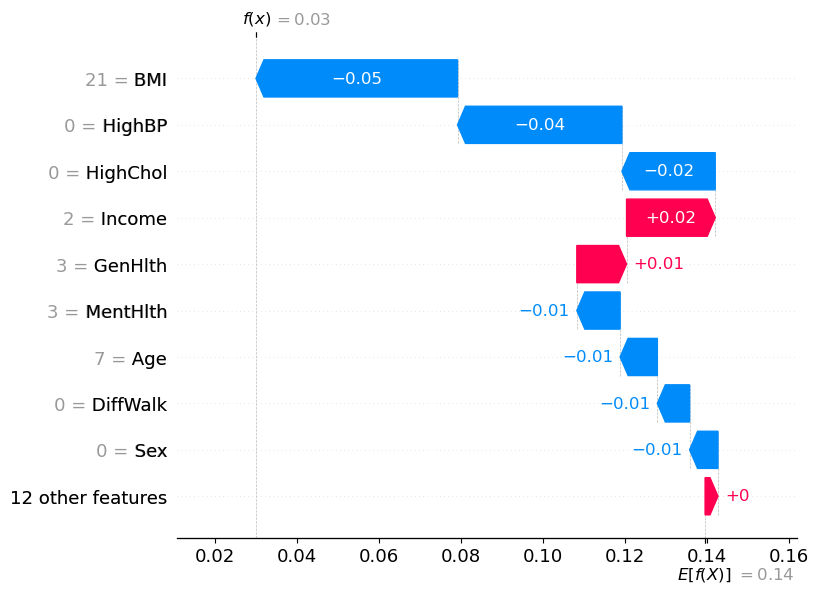

Case 2 - Actual label: 0.0


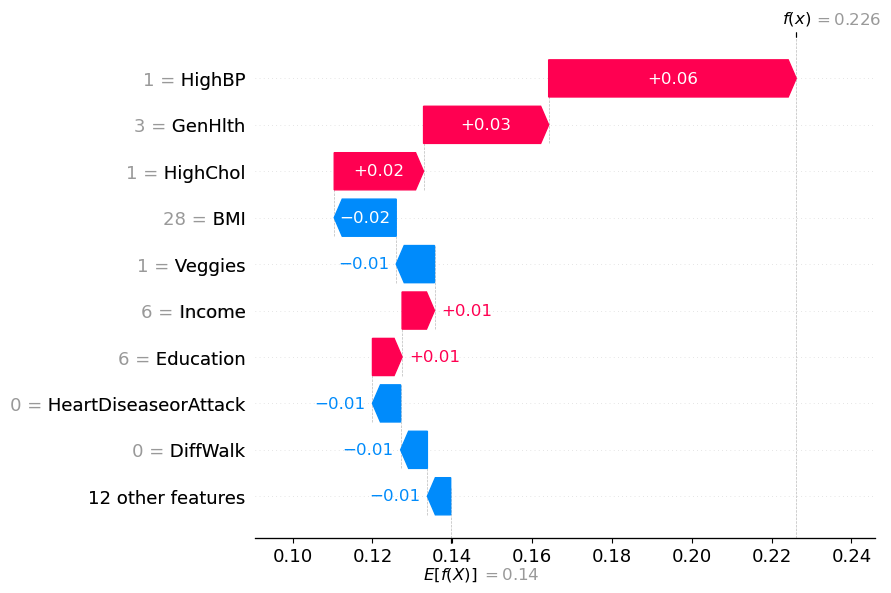

In [8]:
import shap
import matplotlib.pyplot as plt

# Initialize SHAP explainer for RandomForest
explainer = shap.TreeExplainer(model)

# Pick two individual cases from the test set
case_1 = X_test.iloc[[0]]
case_2 = X_test.iloc[[1]]

# Calculate SHAP values for both cases
shap_values_case1 = explainer(case_1)
shap_values_case2 = explainer(case_2)

# Plot local explanation for case 1
print("Case 1 - Actual label:", y_test.iloc[0])
shap.plots.waterfall(shap_values_case1[:, :, 1][0])

# Plot local explanation for case 2
print("Case 2 - Actual label:", y_test.iloc[1])
shap.plots.waterfall(shap_values_case2[:, :, 1][0])

Your interpretation here:


Case 1 Interpretation:

This person has a predicted probability of having diabetes of 0.03 (3%), which is much lower than the dataset average of 0.14 (14%). The model is strongly predicting that this person does not have diabetes.

The two main reasons for this low prediction are:

BMI (value = 21, SHAP = -0.05): This person has a BMI of 21, which falls in the healthy weight range. A low BMI is strongly associated with lower diabetes risk, and the model reflects this by reducing the predicted probability by 0.05.

HighBP (value = 0, SHAP = -0.04): This person does not have high blood pressure. Since high blood pressure is one of the strongest indicators of diabetes in this dataset, its absence is bringing the prediction down by 0.04.

While factors like lower income and poorer general health (GenHlth = 3, SHAP = +0.01) nudge the prediction slightly upward, their combined effect is small and not enough to overcome the strong protective effect of a healthy BMI and absence of high blood pressure.

==========================================================================================

Case 2 Interpretation:

This person has a predicted probability of having diabetes of 0.226 (22.6%), which is notably higher than the dataset average of 0.14 (14%). While the model is not predicting diabetes with certainty, it is flagging this person as having a elevated risk compared to an average person in the dataset.

The two main reasons for this higher prediction are:

HighBP (value = 1, SHAP = +0.06): This person has high blood pressure, which is pushing the prediction upward by 0.06. High blood pressure is a risk factor for diabetes, and the model reflects this by giving it the highest positive contribution for this individual.

GenHlth (value = 3, SHAP = +0.03): This person rated their general health as 3, which represents a moderate health level on the scale. This self-reported general health score suggests the person is not in particularly good health, which the model associates with higher diabetes risk, contributing additional +0.03 to the prediction.

While factors like BMI (value = 28, SHAP = -0.02) and eating vegetables (Veggies = 1, SHAP = -0.01) provide some effect by pulling the prediction slightly downward, they are not strong enough to offset the risk introduced by high blood pressure and moderate general health.

**✏️ Task 7.5 - Global Explanations**  
*Now generate global SHAP visualizations and interpret global feature importance in terms of SHAP for at least two features. If a simple approach takes to much time to converge, try a sampling approach.*

Global Feature Importance (Mean Absolute SHAP values):


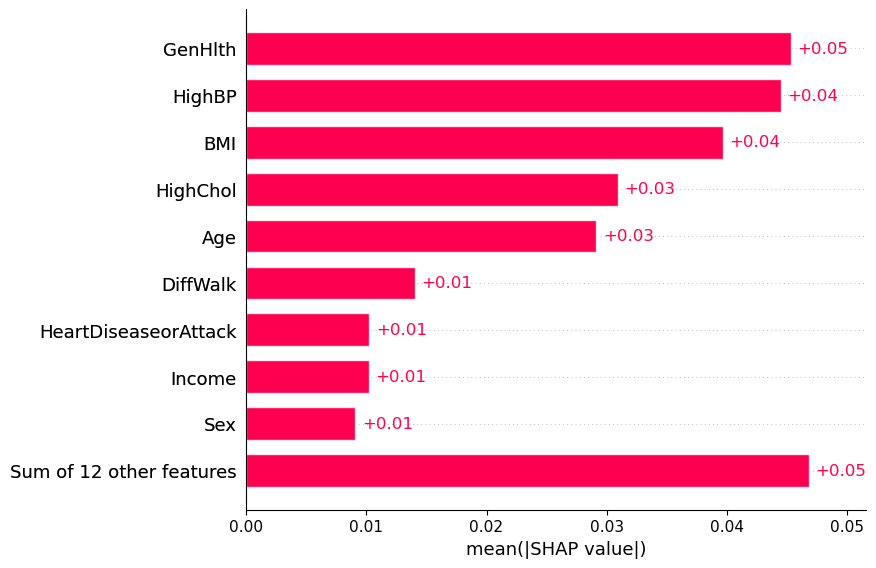

Global Feature Importance (Beeswarm plot):


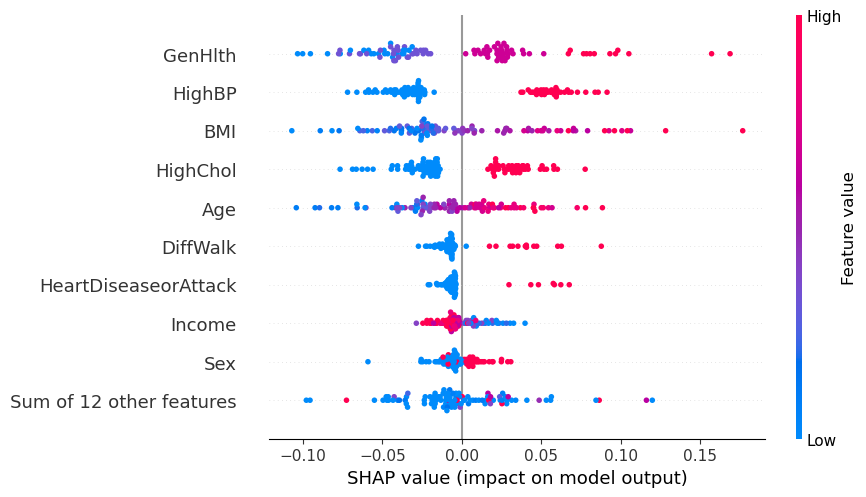

In [9]:
import shap
import matplotlib.pyplot as plt

# Use a sample of test data to speed up computation
X_test_sample = X_test.sample(100, random_state=42)

# Initialize SHAP explainer for RandomForest
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the sample
shap_values = explainer(X_test_sample)

# Global explanation - Summary plot (bar)
print("Global Feature Importance (Mean Absolute SHAP values):")
shap.plots.bar(shap_values[:, :, 1])

# Global explanation - Beeswarm plot
print("Global Feature Importance (Beeswarm plot):")
shap.plots.beeswarm(shap_values[:, :, 1])

Global Feature Importance - Bar Plot Interpretation:

The bar plot ranks features by their Mean Absolute SHAP value across all 100 sampled test cases, showing which features have the greatest overall influence on the model's diabetes predictions on average.

GenHlth (SHAP = 0.05): General health is one of the most influential feature globally. On average, a person's self-reported general health status shifts the model's predicted diabetes probability by 0.05 in either direction. How healthy a person feels overall is the strongest signal the model uses to make its predictions.

HighBP (SHAP = 0.04): High blood pressure is the second most influential feature, tied with BMI. On average, whether or not a person has high blood pressure moves the prediction by 0.04. This is consistent with what we saw in the local explanations for both Case 1 and Case 2, where HighBP was also one of the dominant features.

BMI (SHAP = 0.04): BMI is equally influential as HighBP globally. On average, a person's BMI shifts the prediction by 0.04, reflecting that body weight is a well known risk factor for diabetes and the model has learned this relationship from the data.

==========================================================================================

Global Feature Importance - Beeswarm Plot Interpretation:

The beeswarm plot adds a layer of detail on top of the bar plot by showing not just how much each feature matters globally, but also in which direction different feature values push the prediction, and how consistently they do so.

GenHlth (General Health): The plot shows a clear pattern - people with poor general health (high GenHlth values, shown in red) have their diabetes probability pushed significantly upward, up to +0.17, while people with good general health (low values, shown in blue) have their probability pushed downward to -0.10. This means general health has a strong and consistent directional effect - the worse you feel, the higher the model rates your diabetes risk.

HighBP (High Blood Pressure): Being a binary feature, the plot shows two clean clusters with no overlap. People with high blood pressure (red dots) consistently shift the prediction to the right between +0.04 and +0.10, while people without high blood pressure (blue dots) consistently shift it to the left down to -0.07. This confirms that high blood pressure is also a strong and reliable predictor of diabetes risk in both directions.

Income (bonus observation): The plot reveals an interesting inverse relationship for income - higher income (red dots) decreases the predicted diabetes probability, while lower income (blue dots) increases it. This suggests the model has learned that socioeconomic status plays a meaningful role against diabetes risk.

---
## 📝 Feedback

We are interested in your feedback in order to improve this course. We will read all of your feedback and evaluate it. What you share may have a direct impact on the rest of the course or future iterations of it.

Write down your feedback on the lecture, the exercises, or the assignments in the Markdown cell below. Furthermore, please note the approximate time it took you to complete the assignment. You may also write about your insights, what you found interesting, or questions that you have.